This script serves as a high-performance diagnostic tool for Cryo-Electron Microscopy (Cryo-EM) data, utilising JAX to perform rapid frequency-domain analysis on 3D density maps. By extracting a central representative slice and applying a 2D Fast Fourier Transform (FFT), the code generates a Power Spectrum that allows researchers to visualise resolution limits and signal-to-noise ratios, which are critical for validating structures like the CRL4-CRBN complex. The implementation includes robust error handling and an environment-agnostic configuration that forces CPU processing to bypass potential GPU driver mismatches, ensuring the pipeline remains stable and portable across different computational infrastructures. This automated approach bridges the gap between raw volumetric data and interpretable structural insights, providing a vital quality-control step before proceeding to atomic model building.

In [2]:
# %pip install --user nvidia-cudnn-cu12==9.8.0.87

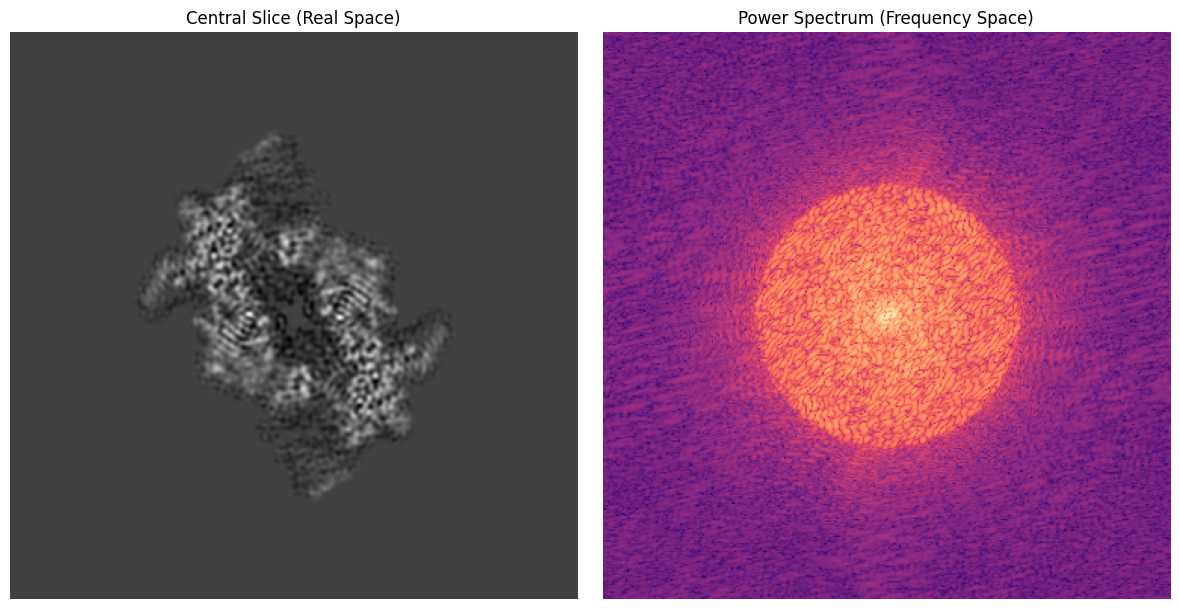

In [1]:
import os
# Force JAX to use CPU to bypass the CuDNN version mismatch error
os.environ['JAX_PLATFORMS'] = 'cpu'

import mrcfile
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

def analyze_with_jax(map_path):
    """
    Analyzes a Cryo-EM map using JAX for high-performance 
    frequency domain diagnostics.
    """
    try:
        # 1. Load data using mrcfile
        with mrcfile.open(map_path) as mrc:
            # Move data to JAX array (now targeting CPU)
            data = jnp.array(mrc.data)
            
        # 2. Extract Central Slice (Real Space)
        # We take the middle slice along the Z-axis
        mid_z = data.shape[0] // 2
        central_slice = data[mid_z, :, :]
        
        # 3. Compute Power Spectrum using JAX FFT
        # fft2 computes the 2D Fourier Transform
        fft_data = jnp.fft.fft2(central_slice)
        fft_shifted = jnp.fft.fftshift(fft_data)
        
        # Calculate log magnitude for better visualization of high-frequency signals
        power_spectrum = jnp.log(jnp.abs(fft_shifted) + 1e-9)
        
        # 4. Visualization
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))
        
        # Display the real-space density slice
        ax[0].imshow(central_slice, cmap='gray')
        ax[0].set_title("Central Slice (Real Space)")
        ax[0].axis('off')
        
        # Display the frequency-space power spectrum
        ax[1].imshow(power_spectrum, cmap='magma')
        ax[1].set_title("Power Spectrum (Frequency Space)")
        ax[1].axis('off')
        
        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"Error: The file at {map_path} was not found.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Example usage:
# Ensure you have already unzipped your .map.gz into this .mrc filename
analyze_with_jax('emd_4343.mrc')